<a href="https://colab.research.google.com/github/packageIncoming/MAT422/blob/main/MAT422_Section_1_2_Linear_Algebra.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# MAT 422 - Section 1.2: Linear Algebra Foundations

**Course:** MAT 422, Mathematical Methods in Data Science, Fall 2026
**Student:** Mert Isik

**Topics covered**
- 1.2.1 Linear spaces
- 1.2.2 Orthogonality
- 1.2.3 Gram-Schmidt process
- 1.2.4 Eigenvalues and eigenvectors

Each section states the mathematical idea, demonstrates it in code, verifies the
result numerically, and interprets the output.

In [40]:
import numpy as np
import matplotlib.pyplot as plt

np.set_printoptions(precision=4, suppress=True)

## 1.2.1 Linear Spaces

A linear space is closed under vector addition and scalar multiplication. In this example, vectors in R3 stay in R3 after we add them or multiply them by scalars. We also show a span calculation: a linear combination of two vectors is still in the same space.

In [41]:

u = np.array([10, -20, 30], dtype=float)
v = np.array([40, 50, -60], dtype=float)
c = 2.5

print("u =", u)
print("v =", v)
print("u + v =", u + v)
print("c * u =", c * u)
print("linear combination u - 2v =", u - 2*v)
print("zero vector =", np.zeros_like(u))
print("additive inverse check u + (-u) =", u + (-u))

u = [ 10. -20.  30.]
v = [ 40.  50. -60.]
u + v = [ 50.  30. -30.]
c * u = [ 25. -50.  75.]
linear combination u - 2v = [ -70. -120.  150.]
zero vector = [0. 0. 0.]
additive inverse check u + (-u) = [0. 0. 0.]


Since u = [10,-20,30] and v = [40,50,-60], both of which are in R3, and the results of u+v, c*u where c=2.5, and u-2v are all in R3, R3 is **closed**.

A useful non-example is the set of vectors in R2 whose first coordinate is exactly 3. It is not a vector space because multiplying by most scalars leaves the set.

In [42]:

w = np.array([3, 2], dtype=float)
scaled_w = 2 * w
print("w =", w)
print("2w =", scaled_w)
print("Is 2w still in the set first coordinate = 3?", np.isclose(scaled_w[0], 3))

w = [3. 2.]
2w = [6. 4.]
Is 2w still in the set first coordinate = 3? False


Multiplying by 2 set the first coordinate to 6 which breaks the rule, therefore it is not a valid vector space.

## 1.2.2 Orthogonality

Two vectors are orthogonal when their dot product is zero. Geometrically, this means the angle between them is 90 degrees. The projection of one vector onto an orthogonal vector has zero length.

a dot b = 0.0
angle in degrees = 90.0
projection of a onto b = [-0. -0.]


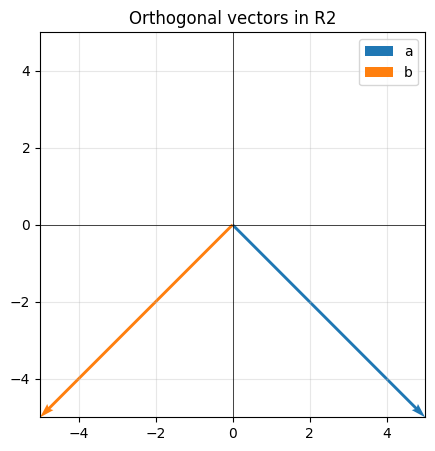

In [43]:
a = np.array([5, -5], dtype=float)
b = np.array([-5, -5], dtype=float)

dot_ab = np.dot(a, b)
angle = np.degrees(np.arccos(dot_ab / (np.linalg.norm(a) * np.linalg.norm(b))))
projection_of_a_on_b = (np.dot(a, b) / np.dot(b, b)) * b

print("a dot b =", dot_ab)
print("angle in degrees =", angle)
print("projection of a onto b =", projection_of_a_on_b)

plt.figure(figsize=(5, 5))
plt.quiver(0, 0, a[0], a[1], angles="xy", scale_units="xy", scale=1, color="tab:blue", label="a")
plt.quiver(0, 0, b[0], b[1], angles="xy", scale_units="xy", scale=1, color="tab:orange", label="b")
plt.xlim(-5, 5)
plt.ylim(-5, 5)
plt.axhline(0, color="black", linewidth=0.5)
plt.axvline(0, color="black", linewidth=0.5)
plt.grid(True, alpha=0.3)
plt.gca().set_aspect("equal", adjustable="box")
plt.legend()
plt.title("Orthogonal vectors in R2")
plt.show()

Visually, it's evident that these two vectors are orthogonal, with a 90* angle formed between vector a and vector b.

## 1.2.3 Gram-Schmidt Process

The Gram-Schmidt process converts a linearly independent set of vectors into an orthonormal basis for the same span. The loop below subtracts projections onto earlier basis vectors, then normalizes the remaining component.

In [44]:
def gram_schmidt(columns):
    basis = []
    for x in columns.T:
        y = x.astype(float).copy()
        for q in basis:
            y -= np.dot(q, y) * q
        norm_y = np.linalg.norm(y)
        if norm_y < 1e-12:
            raise ValueError("Input vectors are linearly dependent or nearly dependent.")
        basis.append(y / norm_y)
    return np.column_stack(basis)

A = np.array([
    [-2, -2, 0],
    [-2, 0, -2],
    [0, -2, -2],
], dtype=float)

Q = gram_schmidt(A)
print("Original column vectors A:")
print(A)
print("\nOrthonormal basis Q:")
print(Q)
print("\nQ.T @ Q should be the identity matrix:")
print(Q.T @ Q)
print("All close to identity?", np.allclose(Q.T @ Q, np.eye(3)))

Original column vectors A:
[[-2. -2.  0.]
 [-2.  0. -2.]
 [ 0. -2. -2.]]

Orthonormal basis Q:
[[-0.7071 -0.4082  0.5774]
 [-0.7071  0.4082 -0.5774]
 [ 0.     -0.8165 -0.5774]]

Q.T @ Q should be the identity matrix:
[[ 1.  0.  0.]
 [ 0.  1. -0.]
 [ 0. -0.  1.]]
All close to identity? True


Since the vectors are orthogonal to all other vectors in the matrix except themselves, performing Q.T @ Q produces zeroes on all off-diagonals and ones on the diagonals, creating the identity matrix.

## 1.2.4 Eigenvalues and Eigenvectors

For a square matrix A, an eigenvector v keeps its direction when multiplied by A. Only its scale changes: `A v = lambda v`, where lambda is the eigenvalue.

In [45]:

M = np.array([
    [0, 4],
    [4, 0],
], dtype=float)

eigenvalues, eigenvectors = np.linalg.eig(M)
print("Matrix M:")
print(M)
print("eigenvalues =", eigenvalues)
print("eigenvectors as columns:")
print(eigenvectors)

for i, lam in enumerate(eigenvalues):
    vec = eigenvectors[:, i]
    residual = M @ vec - lam * vec
    print(f"\nEigenpair {i+1}")
    print("lambda =", lam)
    print("v =", vec)
    print("M @ v =", M @ vec)
    print("lambda * v =", lam * vec)
    print("residual norm =", np.linalg.norm(residual))

Matrix M:
[[0. 4.]
 [4. 0.]]
eigenvalues = [ 4. -4.]
eigenvectors as columns:
[[ 0.7071 -0.7071]
 [ 0.7071  0.7071]]

Eigenpair 1
lambda = 4.0
v = [0.7071 0.7071]
M @ v = [2.8284 2.8284]
lambda * v = [2.8284 2.8284]
residual norm = 0.0

Eigenpair 2
lambda = -4.0
v = [-0.7071  0.7071]
M @ v = [ 2.8284 -2.8284]
lambda * v = [ 2.8284 -2.8284]
residual norm = 0.0


This specific selection of [0,4] [4,0], when normalized, is the reflection matrix. It is both symmetric and orthogonal, but eigenvectors are not always orthogonal.

## Reflection and Submission Checklist

- [X] I explained each concept in words before or after the code.
- [X] I verified important claims numerically, such as dot products, norms, identities, or residuals.
- [X] I changed or extended at least one example so the notebook reflects my own work.
- [X] I ran the notebook from top to bottom without errors.
- [X] I saved the notebook from Google Colab directly to GitHub, following the course instructions.